# BI Copilot — Walmart Sales
**Goal:** Build a Business Intelligence agent with SQL + Plotly visualization on Walmart Sales data

## Libraries

In [1]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain

from langgraph.graph import END, StateGraph
from typing import TypedDict, Optional

import pandas as pd
import sqlalchemy as sql

import os
import re
import yaml
from pprint import pprint
from IPython.display import display

C:\Users\User\AppData\Local\Temp\ipykernel_13908\2155708911.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


## AI Setup

In [2]:
os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

## 1.0 Database Connection — Walmart Sales

In [3]:
PATH_DB = "sqlite:///../data/walmart_sales.db"

sql_engine = sql.create_engine(PATH_DB)
conn = sql_engine.connect()

db = SQLDatabase.from_uri(PATH_DB)
print("Tables:", db.get_usable_table_names())
print("\nSchema:\n", db.get_table_info())

Tables: ['daily_demand']

Schema:
 
CREATE TABLE daily_demand (
	item_id TEXT, 
	value INTEGER, 
	date TEXT
)

/*
3 rows from daily_demand table:
item_id	value	date
FOODS_3_090	1046	2011-01-29
FOODS_3_090	1036	2011-01-30
FOODS_3_090	673	2011-01-31
*/


## 2.0 Utilities

In [4]:
def extract_sql_code(text: str):
    if not text:
        return None
    m = re.search(r"SQLQuery:\s*```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```[\w]*\s*(SELECT[\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"(SELECT[\s\S]+?)(?:;|\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip().rstrip(';')
    return None
    m = re.search(r"SQLQuery:\s*```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"```[\w]*\s*(SELECT[\s\S]+?)```", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip()
    m = re.search(r"(SELECT[\s\S]+?)(?:;|\n\n|$)", text, re.IGNORECASE)
    if m: return m.group(1).strip().rstrip(';')
    return None
    # 1) SQLQuery: ```sql ... ```
    m = re.search(r"SQLQuery:\s*```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 2) ```sql ... ```
    m = re.search(r"```sql\s*([\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 3) ``` ... ``` containing SELECT
    m = re.search(r"```[\w]*\s*(SELECT[\s\S]+?)```", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 4) SQLQuery: SELECT ... (no fence)
    m = re.search(r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)", text, re.IGNORECASE)
    if m:
        return m.group(1).strip()
    # 5) Bare SELECT ...
    m = re.search(r"(SELECT[\s\S]+?)(?:;|\n\n|$)", text, re.IGNORECASE)
    if m:
        return m.group(1).strip().rstrip(";")
    return None




## 3.0 LangGraph BI Agent

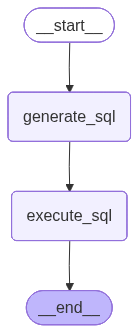

In [5]:
sql_chain = create_sql_query_chain(llm=llm, db=db, k=int(1e7))


class BIState(TypedDict):
    user_question: str
    sql_query: Optional[str]
    data: Optional[list]


def generate_sql(state):
    print("---GENERATE SQL---")
    raw = sql_chain.invoke({"question": state["user_question"]})
    return {"sql_query": extract_sql_code(raw)}


def execute_sql(state):
    print("---EXECUTE SQL---")
    df = pd.read_sql(state["sql_query"], conn)
    return {"data": df.to_dict(orient="records")}


workflow = StateGraph(BIState)
workflow.add_node("generate_sql", generate_sql)
workflow.add_node("execute_sql", execute_sql)
workflow.set_entry_point("generate_sql")
workflow.add_edge("generate_sql", "execute_sql")
workflow.add_edge("execute_sql", END)

app = workflow.compile()
app

## 4.0 Test: Table Query

In [6]:
result = app.invoke({"user_question": "How many rows and unique items are in the daily_demand table?"})
print("SQL:", result.get('sql_query'))
pd.DataFrame(result.get('data', []))

---GENERATE SQL---


---EXECUTE SQL---
SQL: SELECT COUNT(*) AS "total_rows", COUNT(DISTINCT "item_id") AS "unique_items" FROM "daily_demand";


,total_rows,unique_items
0,22956,12


In [7]:
result = app.invoke({"user_question": "What are the top 10 items by total cumulative demand value?"})
print("SQL:", result.get('sql_query'))
pd.DataFrame(result.get('data', []))

---GENERATE SQL---


---EXECUTE SQL---
SQL: SELECT "item_id", SUM("value") AS "total_demand"
FROM "daily_demand"
GROUP BY "item_id"
ORDER BY "total_demand" DESC
LIMIT 10;


,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


## 5.0 Additional Queries

In [8]:
# Monthly demand trend
result = app.invoke({
    "user_question": "What is the total demand value by year-month? Order chronologically."
})

print("SQL:", result.get('sql_query'))
pd.DataFrame(result.get('data', []))

---GENERATE SQL---


---EXECUTE SQL---
SQL: SELECT strftime('%Y-%m', "date") AS "year_month", SUM("value") AS "total_demand"
FROM daily_demand
GROUP BY "year_month"
ORDER BY "year_month" ASC
LIMIT 10000000;


,year_month,total_demand
0,2011-01,9758
1,2011-02,69217
2,2011-03,64767
3,2011-04,69084
4,2011-05,69958
...,...,...
59,2015-12,70503
60,2016-01,80705
61,2016-02,88471
62,2016-03,89161


In [9]:
# Top 15 items by average daily demand
result = app.invoke({
    "user_question": "What is the average daily demand per item? Return top 15 items ordered by average descending."
})

print("SQL:", result.get('sql_query'))
pd.DataFrame(result.get('data', []))

---GENERATE SQL---


---EXECUTE SQL---
SQL: SELECT "item_id", AVG("value") AS "average_demand" 
FROM "daily_demand" 
GROUP BY "item_id" 
ORDER BY "average_demand" DESC 
LIMIT 15;


,item_id,average_demand
0,FOODS_3_090,524.061160
1,FOODS_3_586,481.046524
2,FOODS_3_252,295.503921
3,FOODS_3_555,256.814950
4,FOODS_3_714,207.094616
5,FOODS_3_587,207.066911
6,FOODS_3_694,203.868792
7,FOODS_3_226,189.797177
8,FOODS_3_202,154.568217
9,FOODS_3_723,148.631992
